=== NEU-DET ===
数据集根目录: C:\Users\zhou\Desktop\yolo26n


=== train 数据集概况 ===
图片数量: 1770
标签文件数量: 1770
总目标框数量: 4125
空标签文件数量（无缺陷）: 0

各类别目标数量：
 0 - crazing        :    681 个目标框
 1 - inclusion      :    996 个目标框
 2 - patches        :    864 个目标框
 3 - pitted_surface :    424 个目标框
 4 - rolled-in_scale:    619 个目标框
 5 - scratches      :    541 个目标框

=== valid 数据集概况 ===
图片数量: 30
标签文件数量: 30
总目标框数量: 64
空标签文件数量（无缺陷）: 0

各类别目标数量：
 0 - crazing        :      8 个目标框
 1 - inclusion      :     15 个目标框
 2 - patches        :     17 个目标框
 3 - pitted_surface :      8 个目标框
 4 - rolled-in_scale:      9 个目标框
 5 - scratches      :      7 个目标框

=== 生成类别分布直方图 ===
✅ Train 类别分布直方图已保存至: C:\Users\zhou\Desktop\yolo26n\class_distribution_train.png


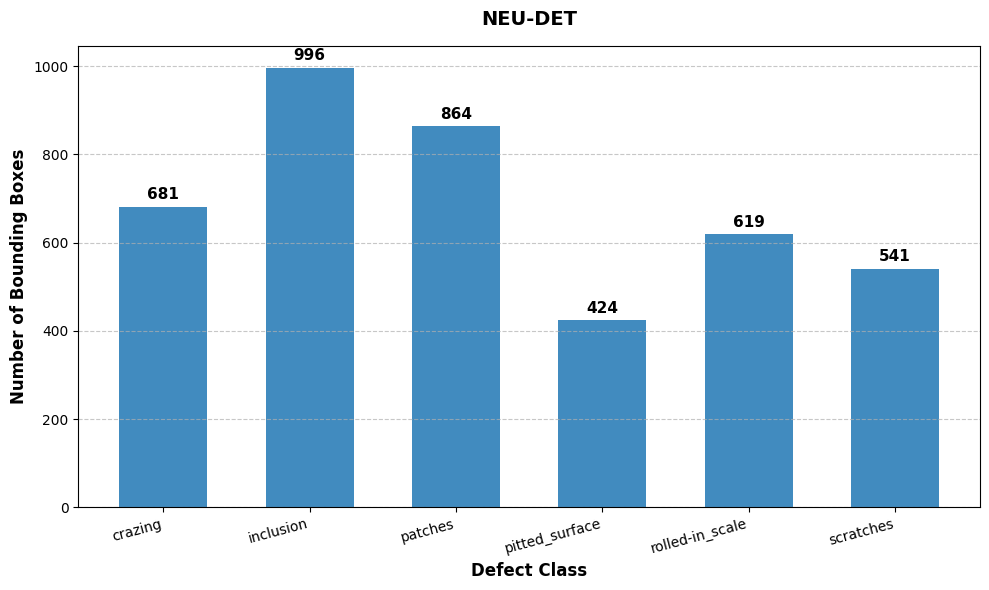

✅ Valid 类别分布直方图已保存至: C:\Users\zhou\Desktop\yolo26n\class_distribution_valid.png


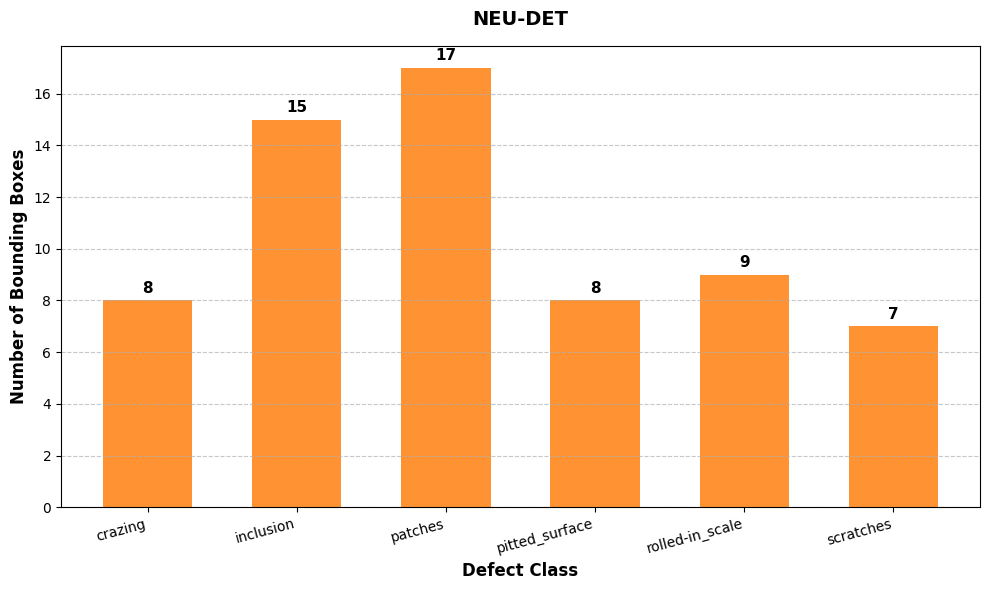

In [5]:
import os
from collections import defaultdict
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import numpy as np

dataset_path = Path(r"C:\Users\zhou\Desktop\yolo26n")
train_images_dir = dataset_path / "train" / "images"
train_labels_dir = dataset_path / "train" / "labels"
val_images_dir = dataset_path / "valid" / "images"
val_labels_dir = dataset_path / "valid" / "labels"

class_names = {
    0: "crazing",
    1: "inclusion",
    2: "patches",
    3: "pitted_surface",
    4: "rolled-in_scale",
    5: "scratches"
}


# ================== 统计函数 ==================
def count_dataset(split_name, images_dir, labels_dir):
    print(f"\n=== {split_name} 数据集概况 ===")
   
    image_files = glob.glob(str(images_dir / "*.jpg")) + \
                  glob.glob(str(images_dir / "*.jpeg")) + \
                  glob.glob(str(images_dir / "*.png"))
    label_files = glob.glob(str(labels_dir / "*.txt"))
   
    print(f"图片数量: {len(image_files)}")
    print(f"标签文件数量: {len(label_files)}")
   
    class_count = defaultdict(int)
    empty_label_count = 0
    total_objects = 0
   
    for label_path in label_files:
        with open(label_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            if not lines or all(not line.strip() for line in lines):
                empty_label_count += 1
                continue
            for line in lines:
                if line.strip():
                    cls_id = int(line.strip().split()[0])
                    class_count[cls_id] += 1
                    total_objects += 1
   
    print(f"总目标框数量: {total_objects}")
    print(f"空标签文件数量（无缺陷）: {empty_label_count}")
   
    print("\n各类别目标数量：")
    for cls_id in range(6):
        count = class_count[cls_id]
        name = class_names[cls_id]
        print(f" {cls_id:1d} - {name:15s}: {count:6d} 个目标框")
    
    return class_count


# ================== 绘制单个数据集的直方图 ==================
def plot_single_histogram(class_count, split_name, color):
    plt.figure(figsize=(10, 6))
    
    classes = list(class_names.values())
    counts = [class_count[i] for i in range(6)]
    x = np.arange(len(classes))
    
    bars = plt.bar(x, counts, color=color, alpha=0.85, width=0.6)
    
    # 在每个柱子顶部显示具体数字
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01, 
                 f'{int(height)}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.xlabel('Defect Class', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Bounding Boxes', fontsize=12, fontweight='bold')
    plt.title(f'NEU-DET', 
              fontsize=14, fontweight='bold', pad=15)
    
    plt.xticks(x, classes, rotation=15, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 自动调整布局
    plt.tight_layout()
    
    # 保存图片
    save_path = dataset_path / f"class_distribution_{split_name.lower()}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ {split_name} 类别分布直方图已保存至: {save_path}")
    
    plt.show()


# ================== 执行统计与绘图 ==================
print("=== NEU-DET ===")
print(f"数据集根目录: {dataset_path}\n")

# 统计 train 和 valid
train_class_count = count_dataset("train", train_images_dir, train_labels_dir)
val_class_count = count_dataset("valid", val_images_dir, val_labels_dir)

# 分别绘制两个直方图
print("\n=== 生成类别分布直方图 ===")
plot_single_histogram(train_class_count, "Train", color='#1f77b4')   # 蓝色
plot_single_histogram(val_class_count, "Valid", color='#ff7f0e')    # 橙色


In [2]:
import torch
print("PyTorch 版本:", torch.__version__)
print("CUDA 是否可用:", torch.cuda.is_available())
print("GPU 数量:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("当前 GPU 名称:", torch.cuda.get_device_name(0))
    

PyTorch 版本: 2.5.1
CUDA 是否可用: True
GPU 数量: 1
当前 GPU 名称: NVIDIA GeForce RTX 3080 Ti Laptop GPU


In [7]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")  

results = model.train(
    data=r"C:\Users\zhou\Desktop\yolo26n\data.yaml", 
    epochs=500,
    imgsz=640,
    batch=16,                    
    device=0,
    patience=50,
    plots=True,
    exist_ok=True,
)


Ultralytics 8.4.36  Python-3.11.15 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3080 Ti Laptop GPU, 16384MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\zhou\Desktop\yolo26n\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=500, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [8]:
# 验证
model.val()


Ultralytics 8.4.36  Python-3.11.15 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3080 Ti Laptop GPU, 16384MiB)
YOLO26n summary (fused): 122 layers, 2,376,006 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 110.874.0 MB/s, size: 10.6 KB)
val: Scanning C:\Users\zhou\Desktop\yolo26n\valid\labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.2s9.7s
                   all         30         64       0.89      0.703      0.821      0.494
               crazing          5          8      0.925      0.375      0.823      0.456
             inclusion          5         15      0.515      0.733      0.595      0.294
               patches          5         17       0.92      0.824      0.933      0.572
        pitted_surface          5          8      0.981          1      0.995       0.65
       rolled-in_scale     

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000241572DFAD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 